<a href="https://colab.research.google.com/github/NadiiaIvashchuk/DTA_2026/blob/main/classmade/pandas_tasks_beginners_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практичні завдання з pandas для початківців

**Мета:** Набути базових навичок роботи з бібліотекою pandas для аналізу табличних даних.

**Інструкції:**
- Виконуйте завдання послідовно — кожне наступне спирається на попередні.
- Після виконання кожного завдання напишіть короткий висновок у комірці `**Висновок:**`.
- Не змінюйте код у комірках з підготовкою даних.

**Набір даних:** Умовна таблиця продажів інтернет-магазину за 2023 рік.

---
## Підготовка: Генерація тестових даних

Запустіть цю комірку перед початком роботи. Не змінюйте код.

In [112]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

categories = ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт']
cities = ['Київ', 'Харків', 'Одеса', 'Дніпро', 'Львів']
payment_methods = ['Картка', 'Готівка', 'Онлайн']

df = pd.DataFrame({
    'order_id':        range(1001, 1001 + n),
    'date':            pd.date_range('2023-01-01', periods=n, freq='D')[:n],
    'category':        np.random.choice(categories, n),
    'product':         ['Товар_' + str(i) for i in np.random.randint(1, 51, n)],
    'city':            np.random.choice(cities, n),
    'quantity':        np.random.randint(1, 10, n),
    'price':           np.round(np.random.uniform(50, 5000, n), 2),
    'payment_method':  np.random.choice(payment_methods, n),
    'rating':          np.random.choice([1, 2, 3, 4, 5, np.nan], n, p=[0.05, 0.1, 0.15, 0.3, 0.3, 0.1]),
    'is_returned':     np.random.choice([True, False], n, p=[0.1, 0.9]),
})

# Додаємо кілька пропущених значень
df.loc[np.random.choice(df.index, 10, replace=False), 'city'] = np.nan
df.loc[np.random.choice(df.index, 5, replace=False), 'price'] = np.nan

# Розраховуємо загальну суму
df['total'] = df['quantity'] * df['price']

print('Дані успішно згенеровано. Рядків:', len(df))
print('Колонки:', list(df.columns))

Дані успішно згенеровано. Рядків: 200
Колонки: ['order_id', 'date', 'category', 'product', 'city', 'quantity', 'price', 'payment_method', 'rating', 'is_returned', 'total']


---
## Завдання 1 (Легке). Перший погляд на дані

Виведіть перші 10 рядків датафрейму `df` та отримайте загальну інформацію про нього (кількість рядків, колонок, типи даних) за допомогою методів `head()` та `info()`.

In [113]:
# Ваш код тут
#df.iloc[4:14, 4:7]
#df.iloc[:5]
df.head(10)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        200 non-null    int64         
 1   date            200 non-null    datetime64[ns]
 2   category        200 non-null    object        
 3   product         200 non-null    object        
 4   city            190 non-null    object        
 5   quantity        200 non-null    int64         
 6   price           195 non-null    float64       
 7   payment_method  200 non-null    object        
 8   rating          177 non-null    float64       
 9   is_returned     200 non-null    bool          
 10  total           195 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 15.9+ KB


**Висновок:** *(Напишіть, скільки рядків і колонок у датафреймі, які типи даних зустрічаються, чи є пропущені значення)*

Dataset:
- 200 rows, 16 columns
- bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
- null values: city(10), price(5), rating(23), total(5)

---
## Завдання 2 (Легке). Описова статистика

Використайте метод `describe()` для отримання описової статистики числових колонок. Окремо виведіть мінімум, максимум і середнє значення колонки `price`.

In [114]:
# Ваш код тут
df.describe()

,order_id,date,quantity,price,rating,total
count,200.000000,200,200.000000,195.000000,177.000000,195.000000
mean,1100.500000,2023-04-10 12:00:00,4.700000,2500.579641,3.813559,11629.097590
min,1001.000000,2023-01-01 00:00:00,1.000000,139.650000,1.000000,149.350000
25%,1050.750000,2023-02-19 18:00:00,2.000000,1288.215000,3.000000,3893.955000
50%,1100.500000,2023-04-10 12:00:00,5.000000,2517.290000,4.000000,8746.840000
75%,1150.250000,2023-05-30 06:00:00,7.000000,3706.975000,5.000000,16922.420000
max,1200.000000,2023-07-19 00:00:00,9.000000,4950.300000,5.000000,44324.640000
std,57.879185,NaN,2.618066,1380.066748,1.169808,9968.293697


**Висновок:** *(Опишіть діапазон цін, середнє значення, чи є суттєвий розкид)*

  Prices:  
- min: 139.65
- avg - 2500.58
- mediane: 2517.29
- max: 4950.30
- std: 1380.07

The average price is 2500.58, while a median price is 2500.58 - distribution is relatively balanced.
The standart deviation is 1380.07, which is more than half of the average price. suggesting a significant spread of prices.

---
## Завдання 3 (Легке). Пропущені значення

Знайдіть кількість пропущених значень у кожній колонці за допомогою `isnull().sum()`. Визначте, який відсоток рядків має пропущені значення хоча б в одній колонці (`dropna()` та `len()`).

In [115]:
# Ваш код тут
df.isnull().sum()

,0
order_id,0
date,0
category,0
product,0
city,10
quantity,0
price,5
payment_method,0
rating,23
is_returned,0


**Висновок:** *(У яких колонках є пропуски, наскільки це критично для аналізу)*

Null columns:
- null values: city(10), price(5), rating(23), total(5)

Most columns have a deviation of less than 10% - it isn`t critical for the study.
The rating column exceed this indicstor, but if it is not the goal of the study, such an excess isn`t critical

---
## Завдання 4 (Легке). Відбір колонок і рядків

Створіть новий датафрейм `df_subset`, що містить лише колонки `order_id`, `category`, `city`, `total`. Потім виведіть рядки з індексами від 10 до 20 включно за допомогою `.iloc[]`.

In [116]:
# Ваш код тут
df_subset = df[['order_id', 'category', 'city', 'total']]
_ # underscore save last intut-code
df_subset.iloc[10:21, 1:]
df_subset[['category', 'city', 'total']]

,category,city,total
0,Продукти,Київ,963.38
1,Спорт,Львів,6517.68
2,Книги,Дніпро,7535.36
3,Спорт,Дніпро,2448.39
4,Спорт,Дніпро,21772.52
...,...,...,...
195,Книги,Львів,10473.00
196,Книги,Львів,2976.81
197,Електроніка,Львів,16200.48
198,Спорт,Одеса,321.07


**Висновок:** *(Поясніть різницю між вибором колонок через список і через `iloc`)*  
Selecting columns using a list and using iloc() achieve similar results but work differently:  
- list - select columns by their names ansd is more readable  
- iloc - select columns by their  integer positions

---
## Завдання 5 (Легке). Фільтрація даних

Відфільтруйте датафрейм і отримайте:
1. Всі замовлення з категорії `'Електроніка'`.
2. Всі замовлення, де `price` перевищує 2000.
3. Поверненi замовлення (`is_returned == True`) з міста `'Київ'`.

Виведіть кількість рядків для кожного фільтру.

In [117]:
# Ваш код тут
print(f"Всі замовлення з категорії 'Електроніка': {len(df[df["category"] == "Електроніка"]) / df.shape[0] * 100}%")
print(f"Всі замовлення, де price перевищує 2000: {len(df[df["price"] > 2000]) / len(df) * 100}%")
display(df[df["price"] > 2000])
print(f"Частка повернень в Києві відносно всіх замовлень в Києві: {len(df[(df["is_returned"] ==True) & (df["city"] == "Київ")]) / len(df[df["city"] == "Київ"]) *100:.2f}%")
print(f"Частка повернень в Києві відносно всіх повернень: {len(df[(df["is_returned"] ==True) & (df["city"] == "Київ")]) / len(df[df["is_returned"] ==True]) *100:.2F}%")
print(df["city"].unique())
returned_by_city = df.groupby("city").agg(count_= ("order_id", "count"), is_ret = ("is_returned", "sum"))
returned_by_city["percent"] = (returned_by_city["is_ret"] / returned_by_city["count_"] * 100).round(2) #sort_values(df["percent"])
display(returned_by_city.sort_values("percent"))

Всі замовлення з категорії 'Електроніка': 21.5%
Всі замовлення, де price перевищує 2000: 57.99999999999999%


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total
3,1004,2023-01-04,Спорт,Товар_11,Дніпро,1,2448.39,Картка,5.0,False,2448.39
4,1005,2023-01-05,Спорт,Товар_48,Дніпро,7,3110.36,Онлайн,3.0,False,21772.52
6,1007,2023-01-07,Книги,Товар_33,Дніпро,4,2339.55,Картка,4.0,False,9358.20
7,1008,2023-01-08,Книги,Товар_9,Львів,4,3749.98,Готівка,4.0,False,14999.92
10,1011,2023-01-11,Продукти,Товар_29,Дніпро,6,3581.08,Готівка,3.0,False,21486.48
...,...,...,...,...,...,...,...,...,...,...,...
193,1194,2023-07-13,Одяг,Товар_22,NaN,8,4608.17,Картка,4.0,False,36865.36
194,1195,2023-07-14,Продукти,Товар_49,Харків,1,4355.99,Готівка,5.0,False,4355.99
195,1196,2023-07-15,Книги,Товар_42,Львів,4,2618.25,Готівка,4.0,False,10473.00
196,1197,2023-07-16,Книги,Товар_6,Львів,1,2976.81,Картка,3.0,False,2976.81


Частка повернень в Києві відносно всіх замовлень в Києві: 18.92%
Частка повернень в Києві відносно всіх повернень: 28.00%
['Київ' 'Львів' 'Дніпро' 'Одеса' 'Харків' nan]


,count_,is_ret,percent
city,,,
Дніпро,38,2,5.26
Харків,39,3,7.69
Львів,46,5,10.87
Київ,37,7,18.92
Одеса,30,7,23.33


**Висновок:** *(Яка частка замовлень відповідає кожному критерію? Що можна сказати про повернення з Києва?)*  
- Electronics orders make up 21.5% of all orders
- 60.5% of orders have a price above 2000
- In Kziv 18.92% of orders were returned but Kyiv accounts for 28% of all returns. Its making Kyiv one of the leading cities by number of returns

---
## Завдання 6 (Середнє). Сортування та ранжування

1. Відсортуйте датафрейм за колонкою `total` у спадному порядку та виведіть топ-10 найбільших замовлень.
2. Додайте нову колонку `rank`, що містить порядковий номер замовлення за розміром суми (від найбільшого до найменшого) за допомогою `.rank()`.

In [118]:
# Ваш код тут
df["rank"] = df["total"].rank(ascending=False, method = "min")
df["rank"]
df.sort_values("total", ascending=False).head(10)


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
190,1191,2023-07-10,Одяг,Товар_22,Київ,9,4924.96,Готівка,4.0,True,44324.64,1.0
58,1059,2023-02-28,Продукти,Товар_33,Харків,9,4848.88,Картка,5.0,False,43639.92,2.0
186,1187,2023-07-06,Спорт,Товар_34,Київ,9,4675.12,Готівка,5.0,False,42076.08,3.0
55,1056,2023-02-25,Електроніка,Товар_3,Дніпро,8,4912.77,Картка,5.0,False,39302.16,4.0
169,1170,2023-06-19,Продукти,Товар_50,Київ,8,4739.05,Готівка,5.0,False,37912.40,5.0
191,1192,2023-07-11,Спорт,Товар_25,Харків,9,4202.55,Готівка,4.0,True,37822.95,6.0
193,1194,2023-07-13,Одяг,Товар_22,NaN,8,4608.17,Картка,4.0,False,36865.36,7.0
51,1052,2023-02-21,Продукти,Товар_35,Дніпро,8,4488.99,Онлайн,4.0,False,35911.92,8.0
25,1026,2023-01-26,Книги,Товар_18,Дніпро,8,4458.11,Картка,3.0,False,35664.88,9.0
143,1144,2023-05-24,Продукти,Товар_31,Київ,9,3732.53,Готівка,5.0,False,33592.77,10.0


**Висновок:** *(Яка максимальна сума замовлення? З яких категорій найбільші замовлення?)*
- max order amount: 44324.64
- category with highest number of orders: "Одяг", "Продукти", "Спорт"

---
## Завдання 7 (Середнє). Групування та агрегація

За допомогою `groupby()` розрахуйте для кожної категорії товарів:
- загальний обсяг продажів (сума `total`),
- кількість замовлень,
- середню ціну (`price`).

Відсортуйте результат за загальним обсягом продажів.

,total_sum,total_count,price_mean
category,,,
Продукти,583761.68,47,2513.979787
Одяг,474135.61,34,2707.906176
Електроніка,428129.79,43,2334.470698
Спорт,400802.56,35,2494.205143
Книги,380844.39,36,2491.881944


<Axes: xlabel='category'>

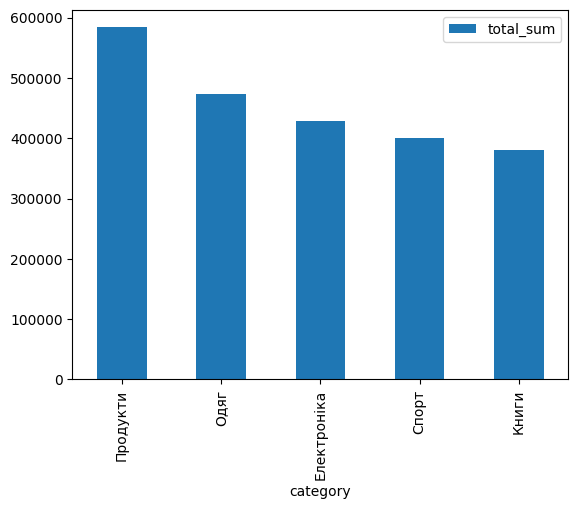

In [119]:
# Ваш код тут
display(df.groupby('category').agg(total_sum = ('total', 'sum'), total_count = ('total', 'count'), price_mean = ('price','mean')).sort_values("total_sum", ascending=False))
display(df.groupby('category').agg(total_sum = ('total', 'sum'), total_count = ('total', 'count'), price_mean = ('price','mean')).sort_values("total_sum", ascending=False).plot(kind="bar", y = "total_sum"))


**Висновок:** *(Яка категорія приносить найбільший дохід? Чи збігається це з кількістю замовлень?)*  
- the most total_sum brings category "Продукти". This indicator coincides with the highest count of orders

---
## Завдання 8 (Середнє). Обробка пропущених значень

1. Заповніть пропущені значення в колонці `price` медіаною цін відповідної категорії (використайте `groupby().transform('median')`).
2. Заповніть пропущені значення в колонці `city` рядком `'Невідомо'`.
3. Пропущені значення в `rating` залиште без змін — поясніть чому у висновку.

Перевірте, що пропусків у `price` та `city` більше немає.

In [120]:
# Ваш код тут
display(df[df["rating"].isna()])
median_price = df.groupby("category")["price"].transform("median")
display(median_price)
df["price"] = df["price"].fillna(median_price)
df["total"] = df["total"].fillna(df["price"] * df["quantity"])
df["city"] = df.city.fillna("Невідомо")
display(df.iloc[66:73])


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
5,1006,2023-01-06,Одяг,Товар_16,Львів,9,1876.12,Онлайн,NaN,False,16885.08,50.0
23,1024,2023-01-24,Електроніка,Товар_40,Львів,1,1671.11,Онлайн,NaN,False,1671.11,181.0
48,1049,2023-02-18,Одяг,Товар_32,Київ,9,973.51,Готівка,NaN,False,8761.59,97.0
50,1051,2023-02-20,Продукти,Товар_41,Львів,6,908.20,Онлайн,NaN,False,5449.20,124.0
63,1064,2023-03-05,Одяг,Товар_36,Дніпро,1,3359.78,Готівка,NaN,False,3359.78,150.0
64,1065,2023-03-06,Одяг,Товар_38,Харків,5,4650.41,Онлайн,NaN,False,23252.05,24.0
67,1068,2023-03-09,Одяг,Товар_35,Харків,6,1435.90,Готівка,NaN,False,8615.40,100.0
70,1071,2023-03-12,Електроніка,Товар_35,Львів,5,1652.21,Готівка,NaN,False,8261.05,103.0
74,1075,2023-03-16,Спорт,Товар_46,Дніпро,2,618.44,Онлайн,NaN,False,1236.88,186.0
75,1076,2023-03-17,Одяг,Товар_18,Одеса,5,3072.57,Картка,NaN,False,15362.85,59.0


,price
0,2740.590
1,2448.390
2,2461.385
3,2448.390
4,2448.390
...,...
195,2461.385
196,2461.385
197,2025.060
198,2448.390


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
66,1067,2023-03-08,Одяг,Товар_20,Одеса,3,2619.055,Готівка,5.0,False,7857.165,NaN
67,1068,2023-03-09,Одяг,Товар_35,Харків,6,1435.900,Готівка,NaN,False,8615.400,100.0
68,1069,2023-03-10,Продукти,Товар_48,Київ,2,3858.990,Готівка,3.0,True,7717.980,108.0
69,1070,2023-03-11,Продукти,Товар_25,Львів,3,975.870,Картка,4.0,False,2927.610,163.0
70,1071,2023-03-12,Електроніка,Товар_35,Львів,5,1652.210,Готівка,NaN,False,8261.050,103.0
71,1072,2023-03-13,Спорт,Товар_25,Дніпро,9,2155.910,Готівка,1.0,False,19403.190,35.0
72,1073,2023-03-14,Спорт,Товар_29,Харків,2,2448.390,Готівка,5.0,False,4896.780,NaN


**Висновок:** *(Чому медіана краща за середнє для заповнення цін? Чому пропуски в rating можна залишити?)*
- The median is more robust to outliers than the mean, making it a better choise for imputation of missing prices
- Missing ratings can be retained as they may represent customers who chose not to leave a rating

---
## Завдання 9 (Середнє). Додавання обчислюваних колонок

Додайте до датафрейму нові колонки:
1. `month` — місяць замовлення (з колонки `date`).
2. `price_category` — категорія ціни: `'Низька'` (до 500), `'Середня'` (500–2000), `'Висока'` (понад 2000). Використайте `pd.cut()` або `np.select()`.
3. `discount_total` — сума зі знижкою 15%.

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank,month,price_category,price_category2,discount_total
0,1001,2023-01-01,Продукти,Товар_34,Київ,1,963.38,Картка,5.0,False,963.38,188.0,1,Середня,Середня,818.87
1,1002,2023-01-02,Спорт,Товар_6,Львів,6,1086.28,Картка,4.0,False,6517.68,117.0,1,Середня,Середня,5540.03
2,1003,2023-01-03,Книги,Товар_22,Дніпро,4,1883.84,Готівка,5.0,False,7535.36,109.0,1,Середня,Середня,6405.06
3,1004,2023-01-04,Спорт,Товар_11,Дніпро,1,2448.39,Картка,5.0,False,2448.39,171.0,1,Висока,Висока,2081.13
4,1005,2023-01-05,Спорт,Товар_48,Дніпро,7,3110.36,Онлайн,3.0,False,21772.52,28.0,1,Висока,Висока,18506.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1196,2023-07-15,Книги,Товар_42,Львів,4,2618.25,Готівка,4.0,False,10473.00,82.0,7,Висока,Висока,8902.05
196,1197,2023-07-16,Книги,Товар_6,Львів,1,2976.81,Картка,3.0,False,2976.81,162.0,7,Висока,Висока,2530.29
197,1198,2023-07-17,Електроніка,Товар_15,Львів,8,2025.06,Онлайн,5.0,False,16200.48,55.0,7,Висока,Висока,13770.41
198,1199,2023-07-18,Спорт,Товар_43,Одеса,1,321.07,Картка,5.0,False,321.07,194.0,7,Низька,Низька,272.91


/tmp/ipykernel_4587/729263849.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = df.groupby("price_category").agg(total_sum = ("total", "sum"), count = ("order_id", "count")).plot(kind = "pie", y = "total_sum")


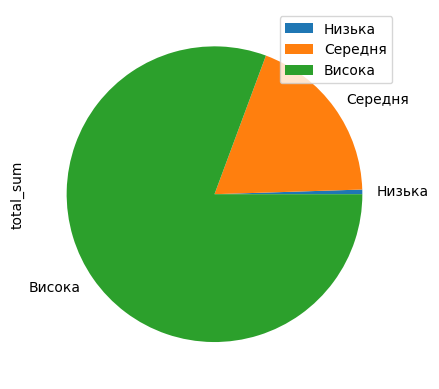

In [121]:
# Ваш код
import numpy as np
df["month"] = df["date"].dt.month
df["price_category"] = pd.cut(df["price"], bins = [0, 500, 2000, float("inf")], labels = ['Низька', 'Середня', 'Висока'])
df["price_category2"] = np.select([df["price"]<500, df["price"]>2000], ['Низька', 'Висока'], default = 'Середня')
df["discount_total"] = (df["total"] * 0.85).round(2)
display(df)
x = df.groupby("price_category").agg(total_sum = ("total", "sum"), count = ("order_id", "count")).plot(kind = "pie", y = "total_sum")

**Висновок:** *(Який розподіл цінових категорій? Як метод pd.cut спрощує категоризацію?)*  
- The share of goods with high ptices is more than 3/4, and less than 1/4 is in the middle price category and a small sharr falls on the low price category
- pd.cut simplifies categoriyation by automatically dividingcontinuous numerical values into meaningful intervals. This makes the data easier to analyse

---
## Завдання 10 (Середнє). Зведена таблиця (pivot table)

Побудуйте зведену таблицю за допомогою `pd.pivot_table()`, де:
- рядки — `city`,
- колонки — `category`,
- значення — сума `total`,
- агрегація — `sum`.

Додайте підсумки по рядках і колонках (`margins=True`).

In [122]:
# Ваш код тут
pd.pivot_table(
  df,
  index = "city",
  columns = "category",
  values  = "total",
  aggfunc = "sum",
  margins = True
).round(2).sort_values("All", ascending=False)


category,Електроніка,Книги,Одяг,Продукти,Спорт,All
city,,,,,,
All,428129.79,398074.08,481992.78,622129.94,405699.34,2336025.93
Харків,44068.06,15669.18,135537.23,199766.70,105100.00,500141.17
Київ,58713.88,87339.03,103754.43,118283.10,113742.95,481833.39
Львів,154285.60,126188.88,74340.69,55768.80,43155.08,453739.06
Дніпро,65438.16,116118.97,31179.87,147336.56,72244.38,432317.94
Одеса,84611.65,26773.57,90218.24,60466.75,65539.34,327609.56
Невідомо,21012.44,25984.45,46962.31,40508.03,5917.59,140384.82


**Висновок:** *(Яке місто і яка категорія дають найбільший сумарний дохід? Що показують margins?)*
- the highest total revenue comes from Kharkiv(500141.17)
- "Продукти" is the category  with the highest overall revenue (622129.94)
- margins=True - adds grand totals

---
## Завдання 11 (Середнє). Підрахунок унікальних значень і частот

1. Підрахуйте кількість унікальних товарів (`product`) у кожній категорії.
2. Виведіть топ-5 найпопулярніших товарів за кількістю замовлень за допомогою `value_counts()`.
3. Визначте частку кожного способу оплати у відсотках (`normalize=True`).

In [123]:
# Ваш код тут
#1 кількість унікальних товарів (product) у кожній категорії
display(df.groupby('category')['product'].nunique())

#2 топ-5 найпопулярніших товарів за кількістю замовлень
display(df['product'].value_counts().head())

#3 часткa кожного способу оплати у відсотках
display(df['payment_method'].value_counts(normalize=True) * 100)

,product
category,
Електроніка,32
Книги,25
Одяг,27
Продукти,30
Спорт,25


,count
product,
Товар_33,11
Товар_48,9
Товар_35,9
Товар_22,7
Товар_20,6


,proportion
payment_method,
Готівка,34.0
Онлайн,33.5
Картка,32.5


**Висновок:** *(Який спосіб оплати найпопулярніший? Чи рівномірний розподіл між способами?)*  
- The most populat payment method is "Готівка", its share is 34%
- The distribution between payment methods is almost even as the shares differ insignificantly

---
## Завдання 12 (Середнє). Аналіз повернень

Розрахуйте рівень повернень (частку повернених замовлень) для кожної категорії та кожного міста. Визначте:
- категорію з найвищим рівнем повернень,
- місто з найнижчим рівнем повернень.

Підказка: використайте `groupby()['is_returned'].mean()`.

In [124]:
# Ваш код тут
#display(df.groupby(['category', 'city'])['is_returned'].mean())
#1
print(f"Kатегорія з найвищим рівнем повернень: {df.groupby('category')['is_returned'].mean().idxmax()}")
#2
print(f"Mісто з найнижчим рівнем повернень: {df.groupby('city')['is_returned'].mean().idxmin()}")

Kатегорія з найвищим рівнем повернень: Одяг
Mісто з найнижчим рівнем повернень: Дніпро


**Висновок:** *(Яка категорія найчастіше повертається? Про що це може свідчити?)*  
- a high rate of return in the category "Одяг". It may indicate issues with sizing, color or quality of product not meeting customers expectations.

---
## Завдання 13 (Підвищена складність). Часовий аналіз

1. Встановіть колонку `date` як індекс датафрейму.
2. Розрахуйте щомісячний обсяг продажів (ресемплінг `resample('ME')` або `resample('M')`, sum по `total`).
3. Знайдіть найкращий і найгірший місяці за продажами.
4. Поверніть звичайний числовий індекс (`reset_index()`).

Hайкращий місяць за продажами: 2023-06-30 00:00:00
Hайкращий місяць за продажами: 2023-07-31 00:00:00


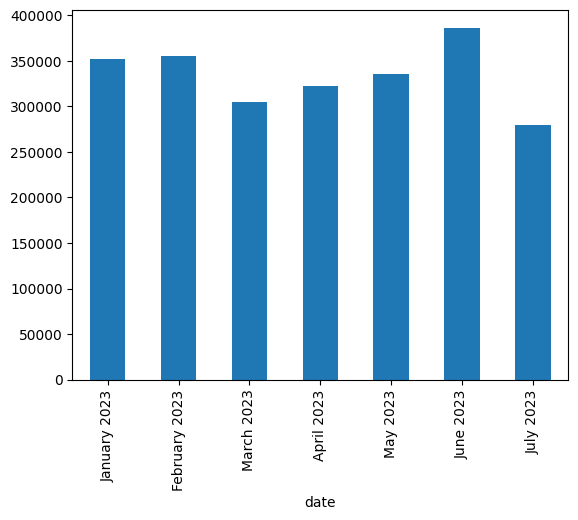

In [125]:
# Ваш код тут
#df["month"] = df["date"].dt.strftime(" %B %Y")
#df.resample("ME", on = "date")["total"].sum().plot(kind = "bar") #dt["date"].dt.strftime("%B %Y")
#1
df = df.set_index('date')
#2
monthly_sales = df['total'].resample('ME').sum()
#3
print(f"Hайкращий місяць за продажами: {monthly_sales.idxmax()}")
print(f"Hайкращий місяць за продажами: {monthly_sales.idxmin()}")

monthly_sales.index = monthly_sales.index.strftime("%B %Y")
monthly_sales.plot(kind='bar')
#4
df.reset_index(inplace=True)

**Висновок:** *(Який місяць виявився найуспішнішим? Чи є сезонність у даних?)*  
- The most successful month - June 2023.
- the set contains data for only 7 months, not enough to determine seasonality


---
## Завдання 14 (Підвищена складність). Накопичувальні показники

1. Відсортуйте датафрейм за датою.
2. Додайте колонку `cumulative_total` — накопичувальний обсяг продажів з початку року (`cumsum()`).
3. Визначте, в який день було досягнуто 50% від загального річного обсягу продажів.

In [139]:
# Ваш код тут
df = df.sort_values('date')
df['cumulative_total'] = df['total'].cumsum()

half_total = df['total'].sum() * 0.5
print(f"B який день було досягнуто 50% від загального річного обсягу продажів: {df.loc[df['cumulative_total'] >= half_total, 'date'].iloc[0]}")


B який день було досягнуто 50% від загального річного обсягу продажів: 2023-04-14 00:00:00


**Висновок:** *(Коли приблизно була зароблена половина річного доходу? Що це означає для бізнесу?)*
- 50% of the annual sales volume was reached on April 14. This indicates that a significant portion of the revenue was already generated in the first third of the year. Thus, sales were unevenly distributed throughout the year, and the business showed higher activity at the beginning of the year

---
## Завдання 15 (Підвищена складність). apply() та lambda

1. Використайте `apply()` з lambda-функцією для створення колонки `total_with_tax`, де ПДВ становить 20%, але лише для замовлень на суму понад 1000 (решта — без змін).
2. Напишіть функцію `classify_rating(r)`, що повертає `'Поганий'` (1–2), `'Нейтральний'` (3), `'Хороший'` (4–5), `'Без оцінки'` (NaN). Застосуйте її до колонки `rating`.

In [147]:
# Ваш код тут
#1
df['total_with_tax'] = df['total'].apply(lambda x: x * 1.2 if x > 1000 else x)

#2
def classify_rating(r):
  if pd.isna(r):
    return 'No rating'
  elif r in [1, 2]:
    return 'Poor'
  elif r in [3]:
    return 'Neutral'
  elif r in [4, 5]:
    return 'Good'

df['rating_class'] = df.rating.apply(classify_rating)

print(f"Яка частка замовлень має хороший рейтинг: {((df['rating_class'] == 'Good').sum() / len(df)) * 100:.2f}%")

Яка частка замовлень має хороший рейтинг: 58.00%


**Висновок:** *(Яка частка замовлень має хороший рейтинг? Коли apply кращий за vectorized-операції?)*
- orders with a good rating is 58%
- apply() is useful for complex logic or custom functions

---
## Завдання 16 (Підвищена складність). Злиття датафреймів (merge)

Створіть додатковий датафрейм `df_discounts` з колонками `category` та `discount_pct` (різні знижки для кожної категорії). Об'єднайте його з основним датафреймом за допомогою `pd.merge()` та розрахуйте `final_total` — суму після застосування відповідної знижки.

```python
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})
```

In [160]:
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})

# Ваш код тут
df_merged = pd.merge(df, df_discounts, on='category', how='left')
df_merged['final_total'] = (df_merged['total'] * (1 - df_merged['discount_pct'])).round(2)
df_merged['discount_amount'] = df_merged['total'] * df_merged['discount_pct']

display(df_merged.groupby('category')['discount_amount'].sum().round(1).sort_values(ascending=False))



,discount_amount
category,
Одяг,96398.6
Спорт,60854.9
Електроніка,42813.0
Книги,19903.7
Продукти,0.0


**Висновок:** *(Яка категорія отримала найбільшу сумарну знижку? Коли варто використовувати merge замість map?)*
- category "Одяг" received the largest total discount
- merge() is used when you need to join several columns from another dataframe, map() is useful for mapping values from a single dictionary or a single column


---
## Завдання 17 (Підвищена складність). Групові трансформації

1. Додайте колонку `city_avg_total` — середня сума замовлення по місту (для кожного рядка підставте середнє по його місту), використайте `groupby().transform('mean')`.
2. Додайте колонку `above_city_avg` — булева колонка, що показує, чи перевищує замовлення середнє по місту.
3. Підрахуйте частку таких замовлень для кожного міста.

In [172]:
# Ваш код тут
df = df_merged
df['city_avg_total'] = df.groupby('city')['total'].transform('mean')

df['above_city_avg'] = df['total'] > df['city_avg_total']

city_share = df.groupby('city')['above_city_avg'].mean().round(2).reset_index(name='share_above_avg')
display(city_share)
city_share.sort_values(by="share_above_avg", ascending=False).head(1)


,city,share_above_avg
0,Дніпро,0.42
1,Київ,0.35
2,Львів,0.35
3,Невідомо,0.40
4,Одеса,0.43
5,Харків,0.44


,city,share_above_avg
5,Харків,0.44


**Висновок:** *(Чим transform відрізняється від звичайного groupby? У якому місті найбільша частка великих замовлень?)*
- Харків has the largest share of large orders
- groupby().transform() returns the result for each row, preserving the original number of rows; the usual groupby().mean() returns a pivot table with fewer rows.


---
## Завдання 18 (Складне). Ковзне середнє та аномалії

1. Згрупуйте дані за місяцем та розрахуйте щоденну виручку.
2. Розрахуйте 7-денне ковзне середнє виручки (`rolling(7).mean()`).
3. Визначте дні-аномалії: дні, коли виручка відхилилася від ковзного середнього більш ніж на 2 стандартних відхилення.

In [193]:
# Ваш код тут
#1
daily_total = df.groupby('date')['total'].sum().round(2).reset_index()

#2
daily_total['rolling_mean'] = daily_total['total'].rolling(7).mean().round(2)
daily_total.head(10)

#3
daily_total['deviation'] = abs(daily_total['total'] - daily_total['rolling_mean'])
std = daily_total['total'].std()

anomalies = daily_total[daily_total['deviation'] > 2 * std]

anomalies[['date', 'total', 'rolling_mean', 'deviation']]
#len(anomalies)

,date,total,rolling_mean,deviation
25,2023-01-26,35664.88,12327.40,23337.48
51,2023-02-21,35911.92,10910.35,25001.57
55,2023-02-25,39302.16,19364.64,19937.52
58,2023-02-28,43639.92,19635.38,24004.54
85,2023-03-27,29701.80,8022.48,21679.32
89,2023-03-31,30810.96,10812.62,19998.34
143,2023-05-24,33592.77,9505.60,24087.17
186,2023-07-06,42076.08,15352.46,26723.62
190,2023-07-10,44324.64,17723.82,26600.82


**Висновок:** *(Скільки аномальних днів виявлено? Що може бути причиною різких відхилень виручки?)*
- anomalous days - 9. The reason for this deviations may be promotions, holidays or some extra large orders

---
## Завдання 19 (Складне). Когортний аналіз

Виконайте спрощений когортний аналіз за місяцем першого замовлення:
1. Для кожного товару (`product`) знайдіть місяць першого продажу — це його «когорта».
2. Об'єднайте цю інформацію з основним датафреймом.
3. Побудуйте зведену таблицю: когорта (місяць першого продажу) проти місяця замовлення, значення — кількість замовлень.

Підказка: використайте `groupby('product')['date'].transform('min')` та `dt.to_period('M')`.

In [199]:
# Ваш код тут
df['cohort'] = df.groupby('product')['date'].transform('min').dt.to_period('M')
df['order_month'] = df['date'].dt.to_period('M')
cohort_table = pd.pivot_table(
    df,
    index = 'cohort',
    columns = 'order_month',
    values = 'product',
    aggfunc = 'count',
    fill_value = 0
)
display(cohort_table)

order_month,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07
cohort,,,,,,,
2023-01,31,15,18,11,14,15,8
2023-02,0,13,6,6,12,8,7
2023-03,0,0,7,6,4,2,1
2023-04,0,0,0,7,1,3,0
2023-06,0,0,0,0,0,2,1
2023-07,0,0,0,0,0,0,2


**Висновок:** *(Що показує когортна таблиця? Чи продовжують товари з першої когорти продаватися в наступних місяцях?)*
- Products from the first cohort continue to be sold in subsequent months. The highest activity is observed in the month of the first sale, after which the number of orders gradually decreases. This indicates a stable demand for the products.

---
## Завдання 20 (Складне). Підсумковий звіт

Сформуйте підсумковий звіт у вигляді одного датафрейму `summary_report`, що містить для кожної категорії:
- загальний дохід (`total_revenue`),
- кількість замовлень (`order_count`),
- середній чек (`avg_order_value`),
- частку доходу від загального (`revenue_share_pct`),
- рівень повернень у відсотках (`return_rate_pct`),
- середній рейтинг без NaN (`avg_rating`).

Відсортуйте за `total_revenue` спадно. Збережіть результат у файл `summary_report.csv`.

In [216]:
# Ваш код тут
summary_report = df.groupby('category').agg(
    total_revenue = ('total', 'sum'),
    order_count = ('order_id', 'count'),
    avg_order_value = ('total', 'mean'),
    return_rate_pct = ('is_returned', lambda x: x.mean()* 100),
    avg_rating = ('rating', 'mean')
)
summary_report = summary_report.round(2)

summary_report['revenue_share_pct'] = (summary_report['total_revenue'] / summary_report['total_revenue'].sum()).round(4) * 100
summary_report = summary_report[
    [
        'total_revenue',
        'order_count',
        'avg_order_value',
        'revenue_share_pct',
        'return_rate_pct',
        'avg_rating'
    ]
]

summary_report = summary_report.sort_values(by='total_revenue', ascending=False)
summary_report.to_csv('summary_report.csv')

summary_report

,total_revenue,order_count,avg_order_value,revenue_share_pct,return_rate_pct,avg_rating
category,,,,,,
Продукти,622129.94,49,12696.53,26.63,6.12,3.91
Одяг,481992.78,35,13771.22,20.63,17.14,3.97
Електроніка,428129.79,43,9956.51,18.33,16.28,3.64
Спорт,405699.34,36,11269.43,17.37,11.11,3.52
Книги,398074.08,37,10758.76,17.04,13.51,4.03


**Висновок:** *(Яка категорія є лідером за доходом? Чи є зв'язок між рейтингом та рівнем повернень? Які рекомендації можна дати бізнесу на основі цього звіту?)*
- leader by revenue: "Продукти"
- The relationship between the level of returns and the rating is traced, however, the obvious influence of additional factors is evident ("Одяг"). The products with the highest rating have the third highest return value
- Businesses are advised to support the development of the "Продукти" category, and also focus on reducing returns in the "Одяг" and "Електроніка" categories, as they have relatively high returns rates

---
## Загальні підсумки

Після виконання всіх завдань дайте відповідь на такі питання:

1. Які методи pandas виявилися для вас найбільш корисними?
2. Які труднощі виникли під час роботи з пропущеними значеннями?
3. Що можна додати до аналізу, щоб зробити його більш повним?

1. groupby(), merge(), agg(), transform(), rolling(), apply()
2. Некоректно працювали ф-ції
3. Графіки